Loading dataset from: c:\Users\Dell\OneDrive\Desktop\Northgate-AI-Stock-Predictor\data\processed\10Y_Treasury.csv
--- ADF Test for DGS10 Raw Close Price ---
ADF Statistic: -0.6111
p-value: 0.8684
Result: Non-Stationary (Fail to Reject Null Hypothesis)

--- ADF Test for DGS10 Daily Returns ---
ADF Statistic: -11.4160
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)



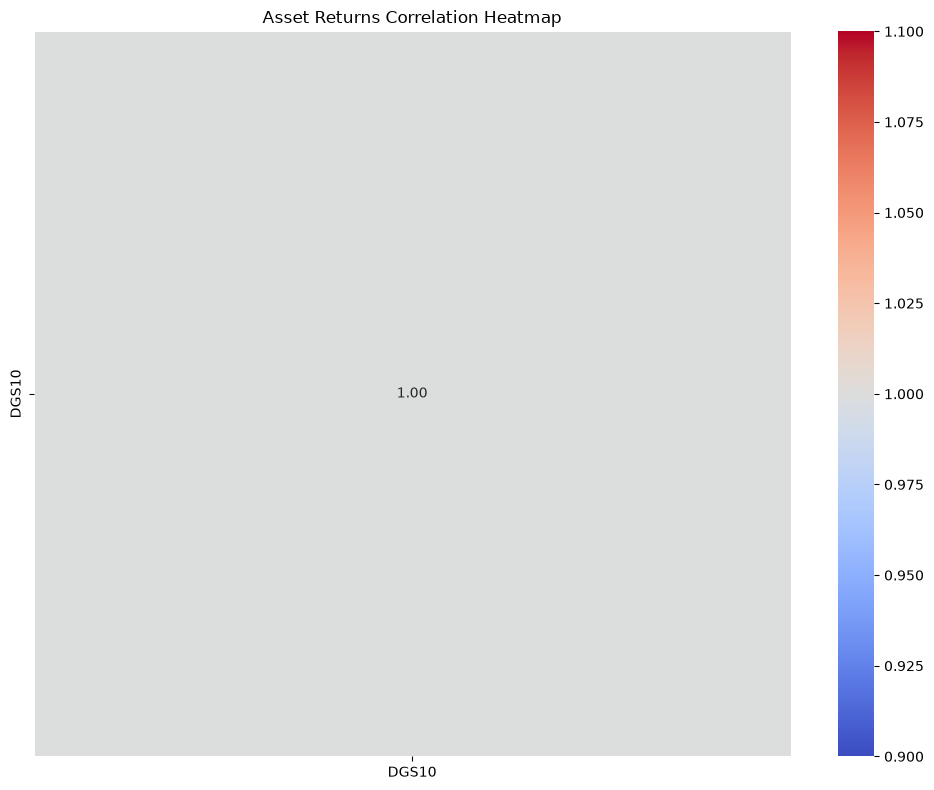

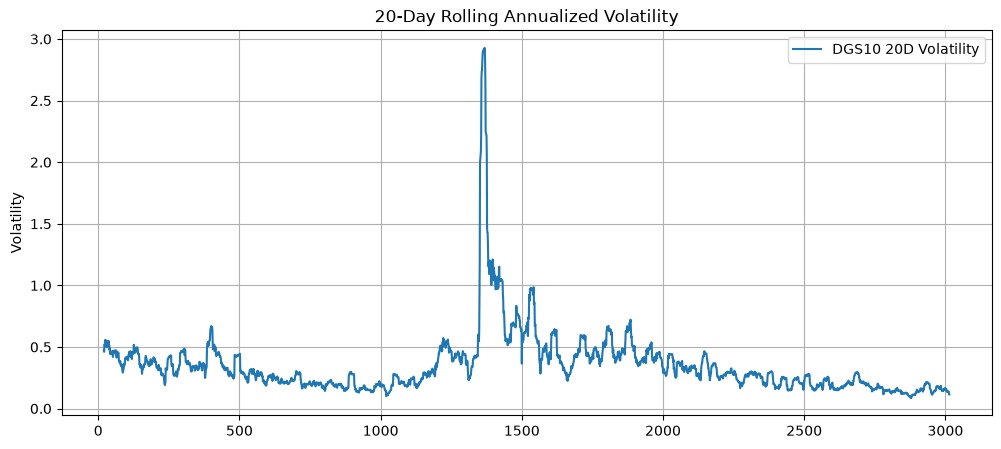

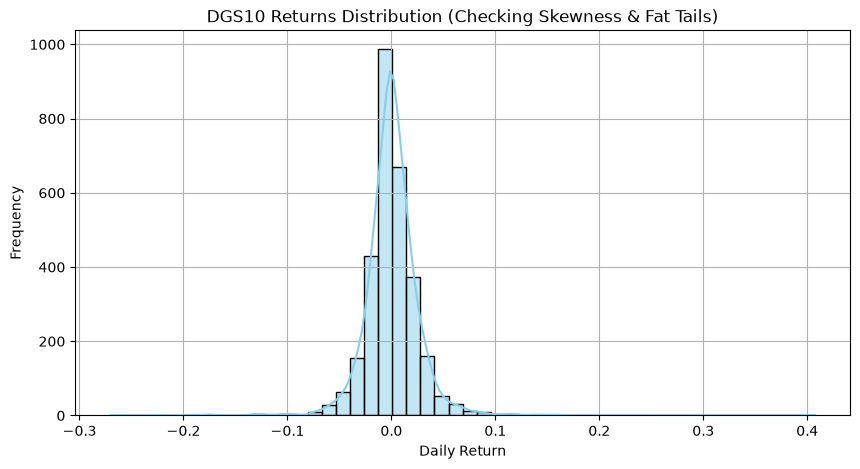

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# --- 1. Set Root Working Directory ---
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")

# --- 2. Dynamically Find Your Processed CSV ---
csv_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")] if os.path.exists(PROCESSED_DIR) else []

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {PROCESSED_DIR}. Run your data ingestion script first!")

# Pick the primary data file (e.g., market_data.csv or features.csv)
target_file = "market_data.csv" if "market_data.csv" in csv_files else csv_files[0]
data_path = os.path.join(PROCESSED_DIR, target_file)

print(f"Loading dataset from: {data_path}")

# --- 3. Load & Pivot Data for Analysis ---
df = pd.read_csv(data_path)

# Handle long format (Ticker, Date, Close) vs wide format (Date as Index)
if "Ticker" in df.columns and "Close" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    price_df = df.pivot(index="Date", columns="Ticker", values="Close")
elif "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    price_df = df.set_index("Date").select_dtypes(include=[np.number])
else:
    price_df = df.select_dtypes(include=[np.number])

# Calculate percentage returns
returns_df = price_df.pct_change().dropna()

# ---------------------------------------------------------
# A. ADF / Stationarity Test
# ---------------------------------------------------------
def run_adf_test(series, name):
    clean_series = series.dropna()
    result = adfuller(clean_series)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)\n")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)\n")

# Run test on first asset in dataset
sample_ticker = price_df.columns[0]
run_adf_test(price_df[sample_ticker], f"{sample_ticker} Raw Close Price")
run_adf_test(returns_df[sample_ticker], f"{sample_ticker} Daily Returns")

# ---------------------------------------------------------
# B. Correlation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(returns_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Asset Returns Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# C. Volatility Analysis
# ---------------------------------------------------------
rolling_vol = returns_df.rolling(window=20).std() * np.sqrt(252) # Annualized Volatility
plt.figure(figsize=(12, 5))
for col in returns_df.columns[:5]:
    plt.plot(rolling_vol[col], label=f"{col} 20D Volatility")
plt.title("20-Day Rolling Annualized Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# D. Distribution Analysis
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(returns_df[sample_ticker], kde=True, bins=50, color="skyblue")
plt.title(f"{sample_ticker} Returns Distribution (Checking Skewness & Fat Tails)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Loading dataset from: c:\Users\Dell\OneDrive\Desktop\Northgate-AI-Stock-Predictor\data\processed\10Y_Treasury.csv
--- ADF Test for DGS10 Raw Close Price ---
ADF Statistic: -0.6111
p-value: 0.8684
Result: Non-Stationary (Fail to Reject Null Hypothesis)

--- ADF Test for DGS10 Daily Returns ---
ADF Statistic: -11.4160
p-value: 0.0000
Result: Stationary (Reject Null Hypothesis)



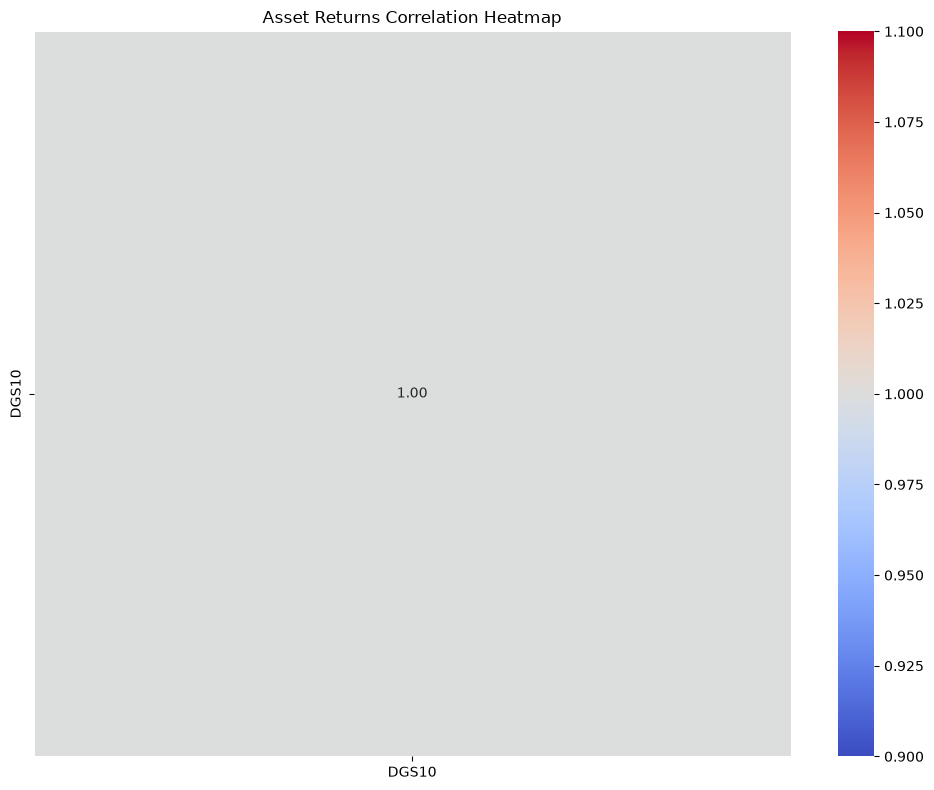

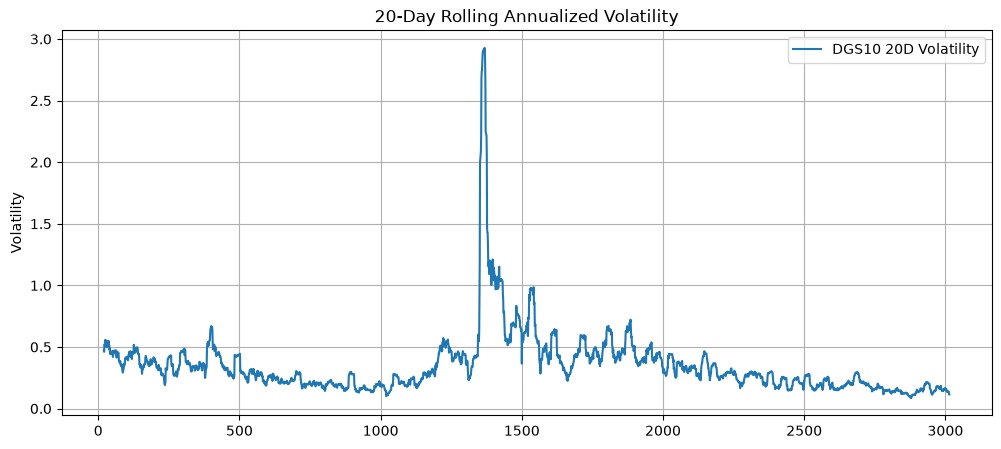

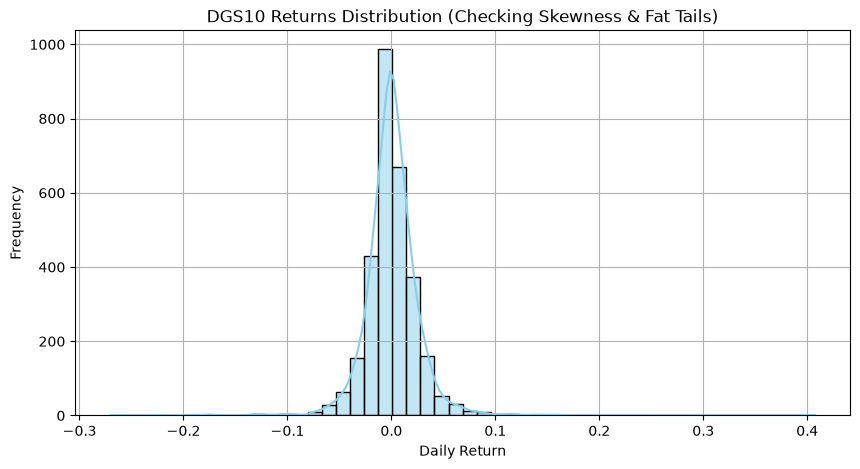

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# --- 1. Set Root Working Directory ---
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")

# --- 2. Dynamically Find Your Processed CSV ---
csv_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")] if os.path.exists(PROCESSED_DIR) else []

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {PROCESSED_DIR}. Run your data ingestion script first!")

# Pick the primary data file (e.g., market_data.csv or features.csv)
target_file = "market_data.csv" if "market_data.csv" in csv_files else csv_files[0]
data_path = os.path.join(PROCESSED_DIR, target_file)

print(f"Loading dataset from: {data_path}")

# --- 3. Load & Pivot Data for Analysis ---
df = pd.read_csv(data_path)

# Handle long format (Ticker, Date, Close) vs wide format (Date as Index)
if "Ticker" in df.columns and "Close" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    price_df = df.pivot(index="Date", columns="Ticker", values="Close")
elif "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    price_df = df.set_index("Date").select_dtypes(include=[np.number])
else:
    price_df = df.select_dtypes(include=[np.number])

# Calculate percentage returns
returns_df = price_df.pct_change().dropna()

# ---------------------------------------------------------
# A. ADF / Stationarity Test
# ---------------------------------------------------------
def run_adf_test(series, name):
    clean_series = series.dropna()
    result = adfuller(clean_series)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)\n")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)\n")

# Run test on first asset in dataset
sample_ticker = price_df.columns[0]
run_adf_test(price_df[sample_ticker], f"{sample_ticker} Raw Close Price")
run_adf_test(returns_df[sample_ticker], f"{sample_ticker} Daily Returns")

# ---------------------------------------------------------
# B. Correlation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(returns_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Asset Returns Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# C. Volatility Analysis
# ---------------------------------------------------------
rolling_vol = returns_df.rolling(window=20).std() * np.sqrt(252) # Annualized Volatility
plt.figure(figsize=(12, 5))
for col in returns_df.columns[:5]:
    plt.plot(rolling_vol[col], label=f"{col} 20D Volatility")
plt.title("20-Day Rolling Annualized Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# D. Distribution Analysis
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(returns_df[sample_ticker], kde=True, bins=50, color="skyblue")
plt.title(f"{sample_ticker} Returns Distribution (Checking Skewness & Fat Tails)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()